<a href="https://colab.research.google.com/github/gyeongee/TIL/blob/main/%EA%B5%B0%EC%A7%91%ED%99%94_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
# 클래스 파라미터
# n_clusters : 군집화할 개수, 군집 중심점의 개수
# init : 군집 중심점의 좌표를 설정할 방식
# max_iter는 최대 반복 횟수이며, 이전에 모든 데이터의 중심점 이동이 없으면 종료
#class sklearn.cluster.KMeans(n_clusters=8,init='k-means++',max_iter=300)

In [27]:
# 객체 속성
# labels_ : 각 데이터 포인트가 속한 군집 중심점 레이블
# cluster_centers_: 각 군집 중심점 좌표(Shape는 [군집 개수, 피처 개수]). 이를 이용하면 군집 중심점 좌표가 어디인지 시각화할 수 있습니다.

In [28]:
# 붓꽆의 꽃받침(sepal)과 꽃잎(petal) 길이와 너비에 따른 품종을 분류
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris=load_iris()
# 더 편리한 데이터 핸들링을 위해 DataFrame으로 변환
iris_df = pd.DataFrame(data=iris.data,columns=iris.feature_names)
iris_df.head(3)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [29]:
iris_df.columns=iris_df.columns.str.replace(' (cm)','',regex=False)

In [30]:
iris_df.columns

Index(['sepal length', 'sepal width', 'petal length', 'petal width'], dtype='object')

In [31]:
# 붓꽃 데이터 세트를 3개 그룹으로 군집화
kmeans=KMeans(n_clusters=3,init='k-means++',max_iter=300,random_state=0)
kmeans.fit(iris_df)

KMeans(n_clusters=3, random_state=0)

In [32]:
print(kmeans.labels_)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [33]:
# 실제 붓꽃 품종 분류 값과의 차이 비교
iris_df['target']=iris.target
iris_df['cluster']=kmeans.labels_
iris_result=iris_df.groupby(['target','cluster'])['sepal length'].count()
print(iris_result)

target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: sepal length, dtype: int64


In [34]:
# 2차원 시각화를 위해 PCA로 차원 축소 진행
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(iris.data)

iris_df['pca_x']=pca_transformed[:,0]
iris_df['pca_y']=pca_transformed[:,1]
iris_df.head(3)

,sepal length,sepal width,petal length,petal width,target,cluster,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,-2.888991,-0.144949


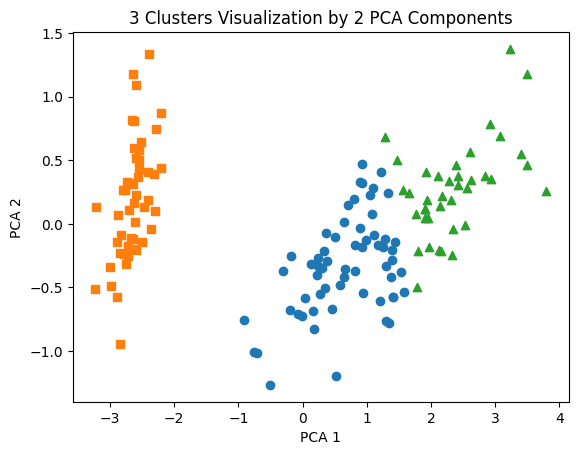

In [35]:
# 군집 값이 0,1,2 인 경우마다 별도의 인덱스로 추출
marker0_ind=iris_df[iris_df['cluster']==0].index
marker1_ind=iris_df[iris_df['cluster']==1].index
marker2_ind=iris_df[iris_df['cluster']==2].index

# 군집 값 0,1,2에 해당하는 인덱스로 각 군집 레벨의 pca_x,pca_y 값 추출
plt.scatter(x=iris_df.loc[marker0_ind,'pca_x'],y=iris_df.loc[marker0_ind,'pca_y'],marker='o')
plt.scatter(x=iris_df.loc[marker1_ind,'pca_x'],y=iris_df.loc[marker1_ind,'pca_y'],marker='s')
plt.scatter(x=iris_df.loc[marker2_ind,'pca_x'],y=iris_df.loc[marker2_ind,'pca_y'],marker='^')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('3 Clusters Visualization by 2 PCA Components')
plt.show()

Cluster 1을 나타내는 네머('s')는 명확히 다른 군집과 잘 분리돼 있습니다.

Cluster 0을 나타내는 동그라미('o')와 Cluster 2를 나타내는 세모('^')는 상당 수준 분리돼 있지만, 네모만큼 명확하게는 분리돼 있지 않음을 알 수 있습니다. Cluster 0과 1의 경우 속성의 위치 자체가 명확히 분리되기 어려운 부분이 존재합니다.

군집화 알고리즘 테스트를 위한 데이터 생성

- make_blobs(): 개별 군집의 중심점과 표준 편차 제어 기능이 추가돼 있음
- make_classification() : 노이즈를 포함한 데이터를 만드는데 사용

> make_blobs() 호출 파라미터
  - n_samples : 생성할 총 데이터의 개수.디폴트 100개
  - n_features : 데이터의 피처 개수입ㄴ디ㅏ.시각화를 목표로 할 경우 2개로 설정해 보통 첫 번째 피처 x 좌표,두 번째 피처는 y 좌표상에 표현합니다.
  - centers : int 값, 예를 들어 3으로 설정하면 군집의 개수를 나타냅니다. 그렇지 않고 ndarray 형태로 표현할 경우 개별 군집 중심점의 좌표를 의미합니다.
  - cluster_std : 생성될 군집 데이터의 표준 편차

In [36]:
from sklearn.datasets import make_blobs
%matplotlib inline

X,y = make_blobs(n_samples=200,n_features=2,centers=3,cluster_std=0.8,random_state=0)

# y target 값의 고유값 분포 확인
# return_counts : 각 고유값 등장 횟수
unique,counts = np.unique(y,return_counts=True)
print(unique,counts)

[0 1 2] [67 67 66]


In [37]:
# DataFrame으로 변경
cluster_df = pd.DataFrame(data=X,columns=['ftr1','ftr2'])
cluster_df['target']=y
cluster_df.head(3)

,ftr1,ftr2,target
0,-1.692427,3.622025,2
1,0.697940,4.428867,0
2,1.100228,4.606317,0


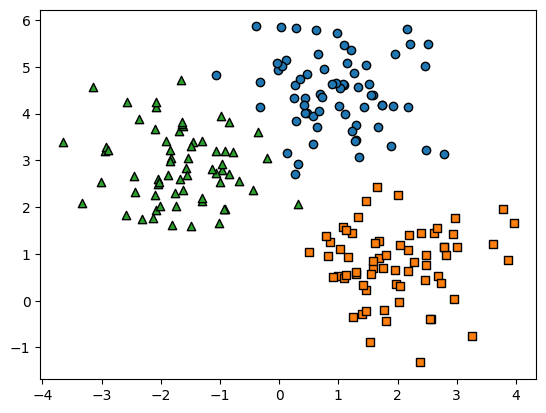

In [38]:
# 군집화 분포 확인
target_list = np.unique(y)
# 각 티켓별 산점도의 마커 값
markers=['o','s','^','P','D','H','x']
# 3개의 군집 영역으로 구분한 데이터 세트를 생성했으므로 target_list는 [0,1,2]
# target=0,target=1,target=2 로 scatter plot을 marker별로 생성
for target in target_list :
  target_cluster = cluster_df[cluster_df['target']==target]
  plt.scatter(x=target_cluster['ftr1'],y=target_cluster['ftr2'],edgecolor='k',
              marker=markers[target])

plt.show()

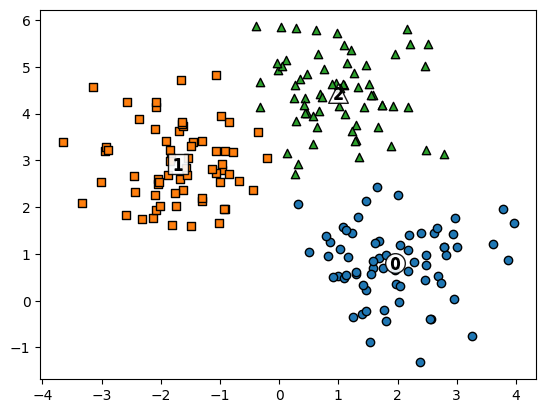

In [39]:
#KMeans 객체를 이용해 X 데이터를 X-Means 클러스터링 수행
kmeans=KMeans(n_clusters=3,init='k-means++',max_iter=200,random_state=0)
cluster_labels=kmeans.fit_predict(X)
cluster_df['kmeans_label']=cluster_labels

#cluster_centers_는 개별 클러스터의 중심 위치 좌표 시각화를 위해 추출
centers=kmeans.cluster_centers_
unique_labels=np.unique(cluster_labels)

markers=['o','s','^','P','D','H','x']

# 군집된 label 유형별로 iteration 하면서 marker 별로 scatter plot 수행
for label in unique_labels:
  label_cluster=cluster_df[cluster_df['kmeans_label']==label]
  center_x_y=centers[label]
  plt.scatter(x=label_cluster['ftr1'],y=label_cluster['ftr2'],edgecolor='k',
              marker=markers[label])

  # 군집별 중심 위치 좌표 시각화
  plt.scatter(x=center_x_y[0],y=center_x_y[1],s=200,color='white',
              alpha=0.9,edgecolor='k',marker=markers[label])
  plt.scatter(x=center_x_y[0],y=center_x_y[1],s=70,color='k',edgecolor='k',
              marker='$%d$' % label)

plt.show()

In [40]:
print(cluster_df.groupby('target')['kmeans_label'].value_counts())

target  kmeans_label
0       2               66
        1                1
1       0               67
2       1               65
        0                1
Name: count, dtype: int64


make_blobs()은 cluster_std 파라미터로 데이터의 분포도를 조절합니다.

### 군집 평가(cluster Evaluation)

- 실루엣 분석(silhouette analysis)

In [44]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

# 실루엣 분석 평가 지표 값을 구하기 위한 API 추가
from sklearn.metrics import silhouette_samples,silhouette_score

kmeans=KMeans(n_clusters=3,init='k-means++',max_iter=300,random_state=0).fit(iris_df)
iris_df['cluster']=kmeans.labels_

# iris의 모든 개별 데이터에 실루엣 계수 값을 구함
score_samples = silhouette_samples(iris.data,iris_df['cluster'])
print(f'silhouette_samples()  return 값의 shape:{score_samples.shape}')

# iris_df에 실루엣 계수 추가
iris_df['silhouette_coef']=score_samples

# 모든 데이터의 평균 실루엣 계수 값을 구함
average_score=silhouette_score(iris.data,iris_df['cluster'])
print(f'붓꽃 데이터 세트 Silhouette Analysis Score:{average_score:.3f}')

silhouette_samples()  return 값의 shape:(150,)
붓꽃 데이터 세트 Silhouette Analysis Score:0.551


In [46]:
# iris_df에서 군집 컬럼별 silhouette_coef 칼럼의 평균
iris_df.groupby('cluster')['silhouette_coef'].mean()

,silhouette_coef
cluster,
0,0.422323
1,0.797604
2,0.436842


In [ ]:
visualize_silhouette([2,3,4,5],X_fetures)

For n_clusters = 2 The average silhouette_score is : 0.7049787496083262
For n_clusters = 3 The average silhouette_score is : 0.5882004012129721
For n_clusters = 4 The average silhouette_score is : 0.6505186632729437
For n_clusters = 5 The average silhouette_score is : 0.561464362648773
For n_clusters = 6 The average silhouette_score is : 0.4857596147013469


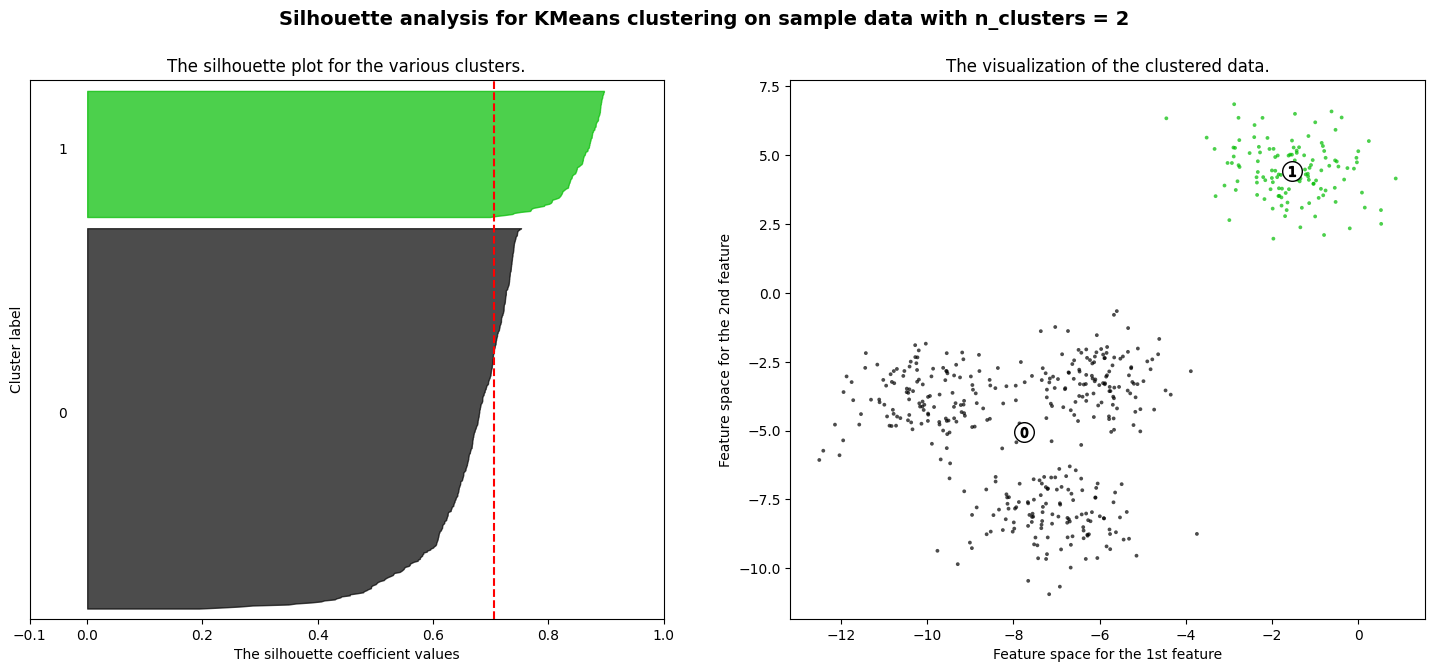

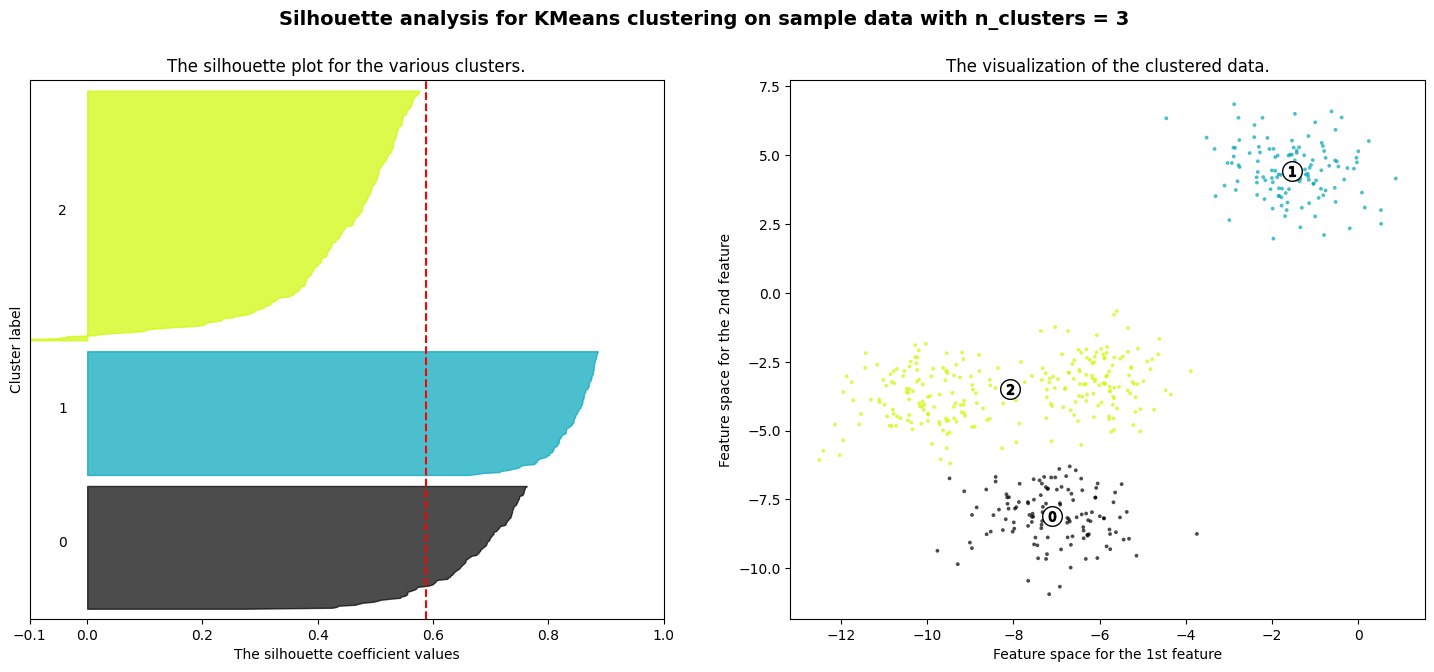

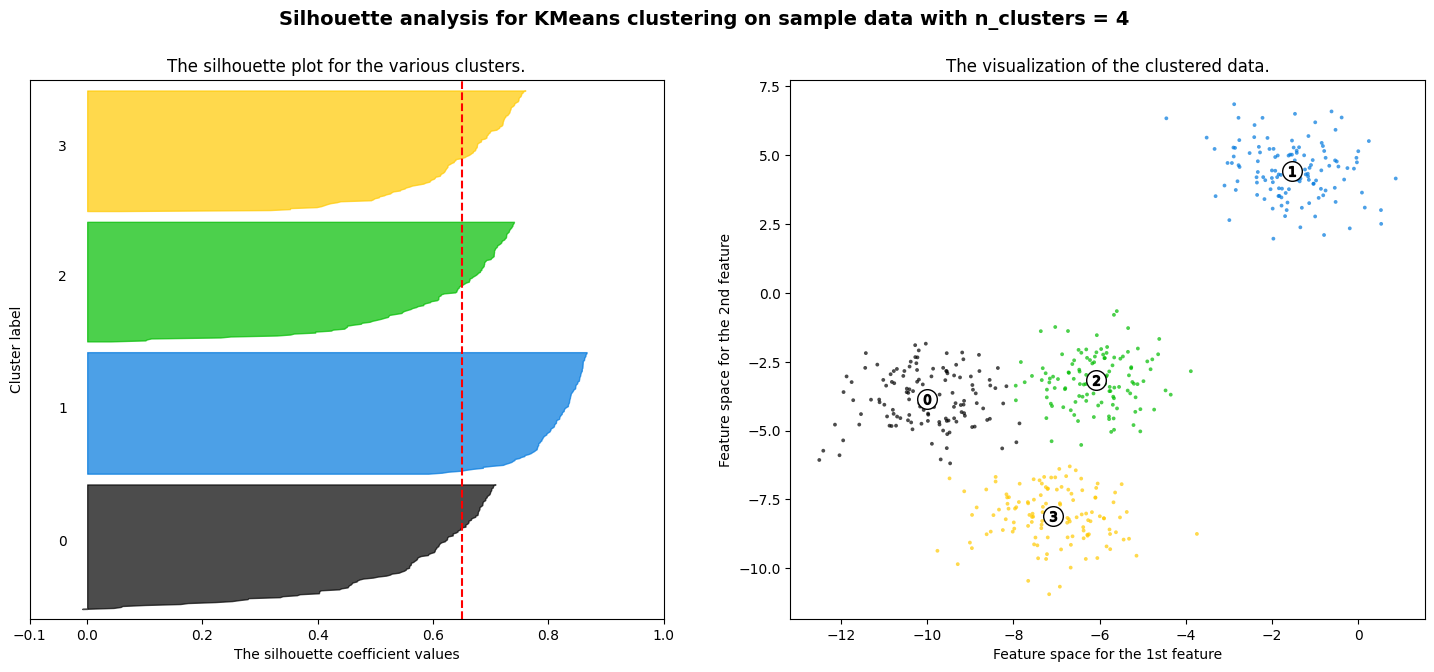

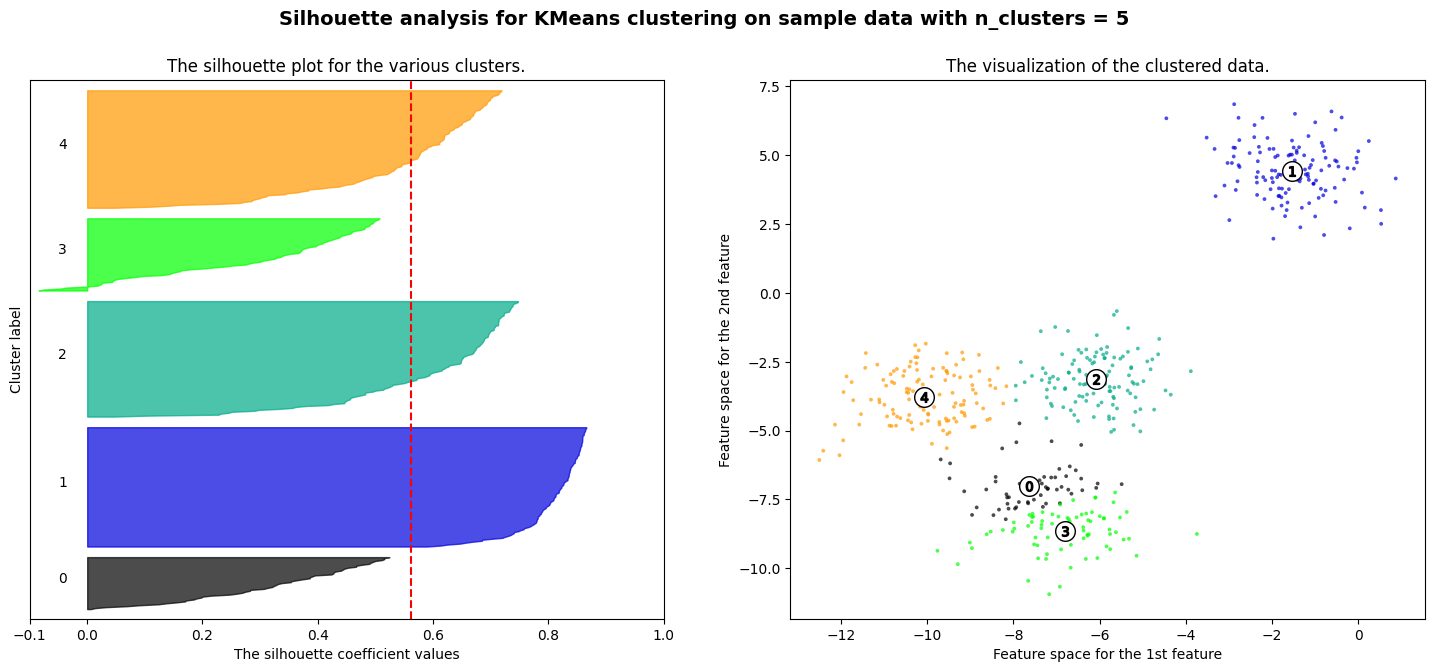

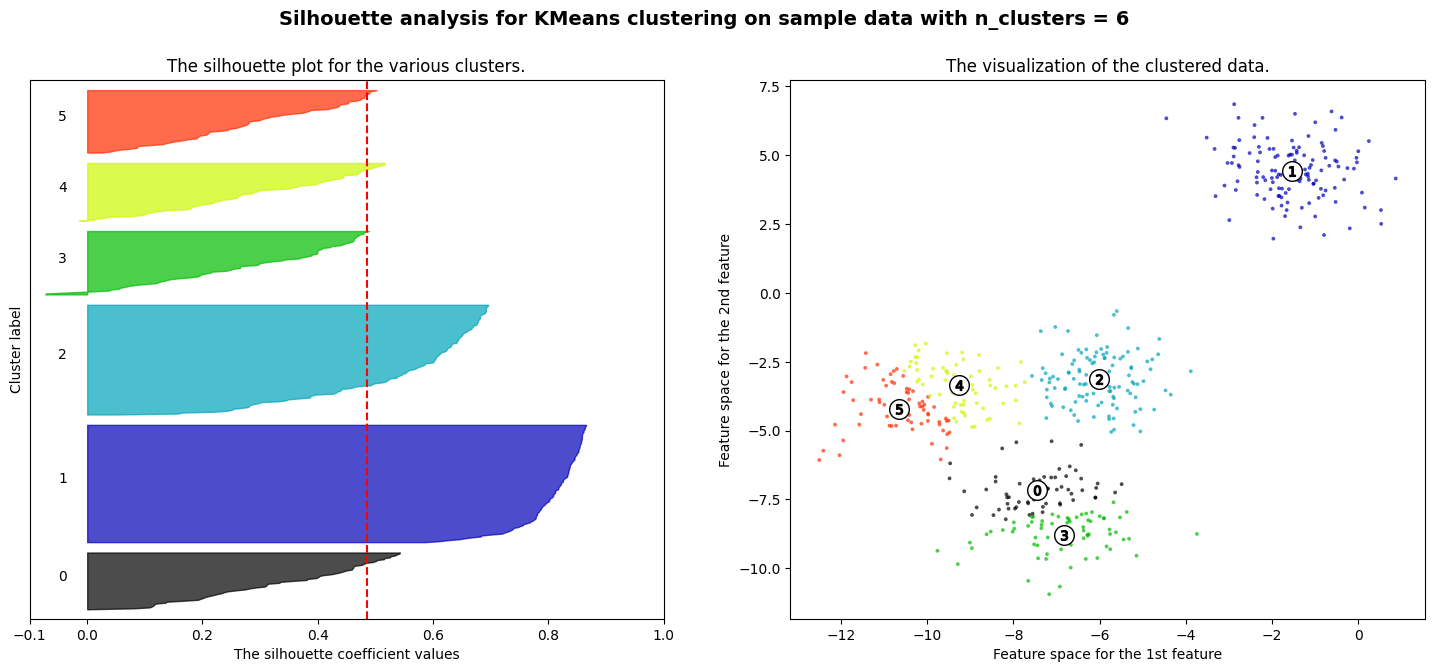

In [47]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_samples, silhouette_score

# Generating the sample data from make_blobs
# This particular setting has one distinct cluster and 3 clusters placed close
# together.
X, y = make_blobs(
    n_samples=500,
    n_features=2,
    centers=4,
    cluster_std=1,
    center_box=(-10.0, 10.0),
    shuffle=True,
    random_state=1,
)  # For reproducibility

range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X[:, 0], X[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

군집이 4개인 경우 개별 군집의 평군 실루엣 계수값이 비교적 균일하게 위치하고 있습니다. 군집이 2개인 경우보다는 평균 실루엣 계수 값이 작지만 4개인 경우가 가장 이상적인 군집화 개수로 판단할 수 있습니다.

For n_clusters = 2 The average silhouette_score is : 0.6810461692117462


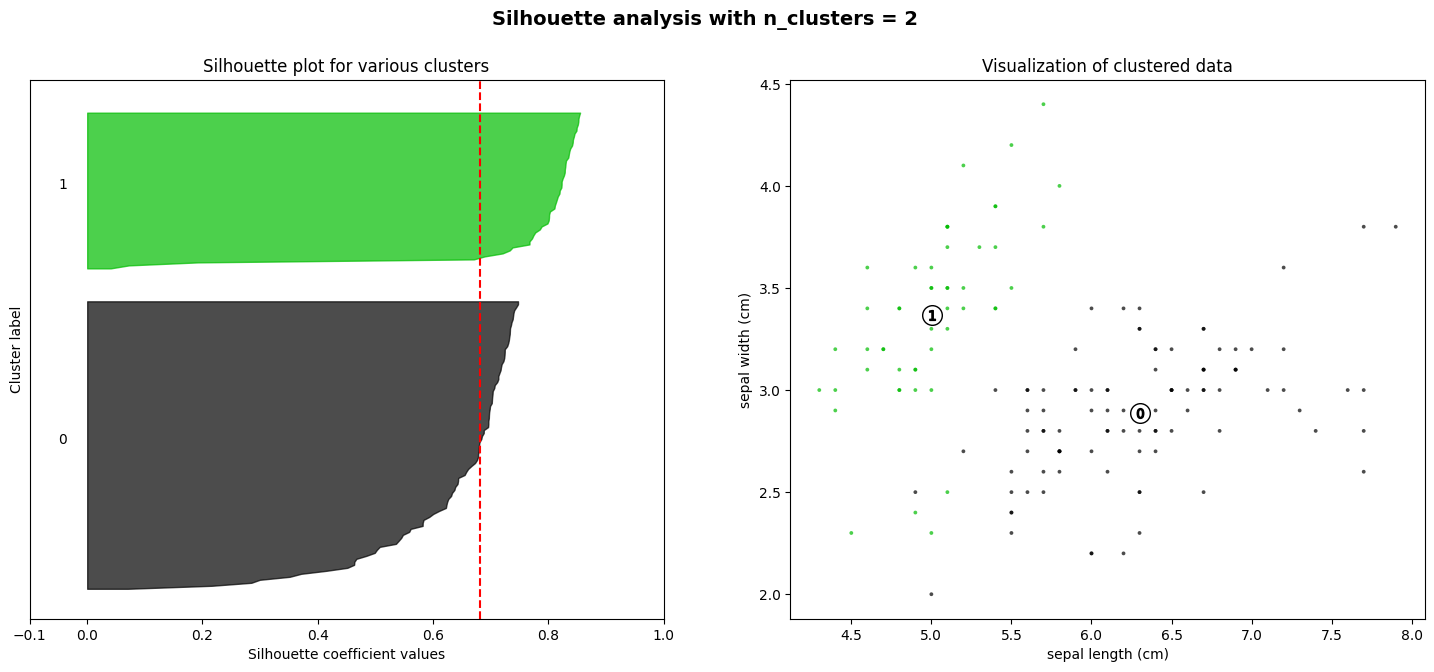

For n_clusters = 3 The average silhouette_score is : 0.551191604619592


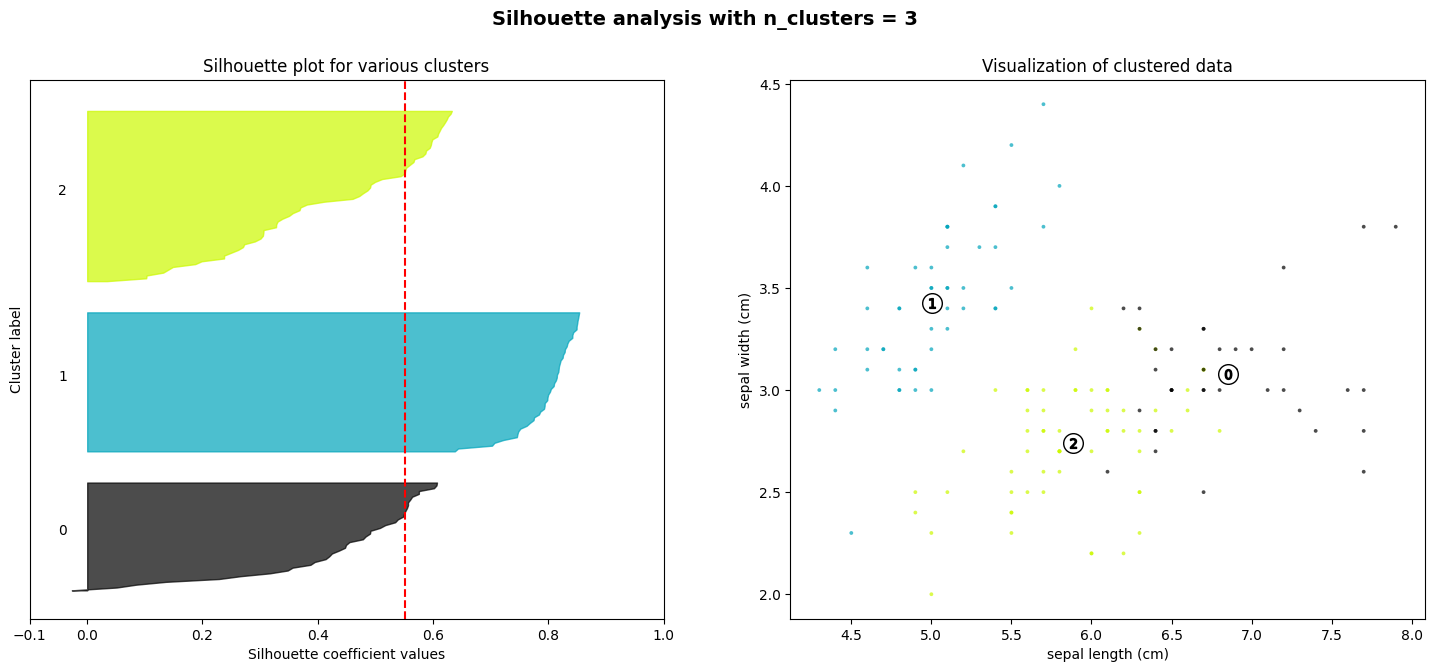

For n_clusters = 4 The average silhouette_score is : 0.49535632852884987


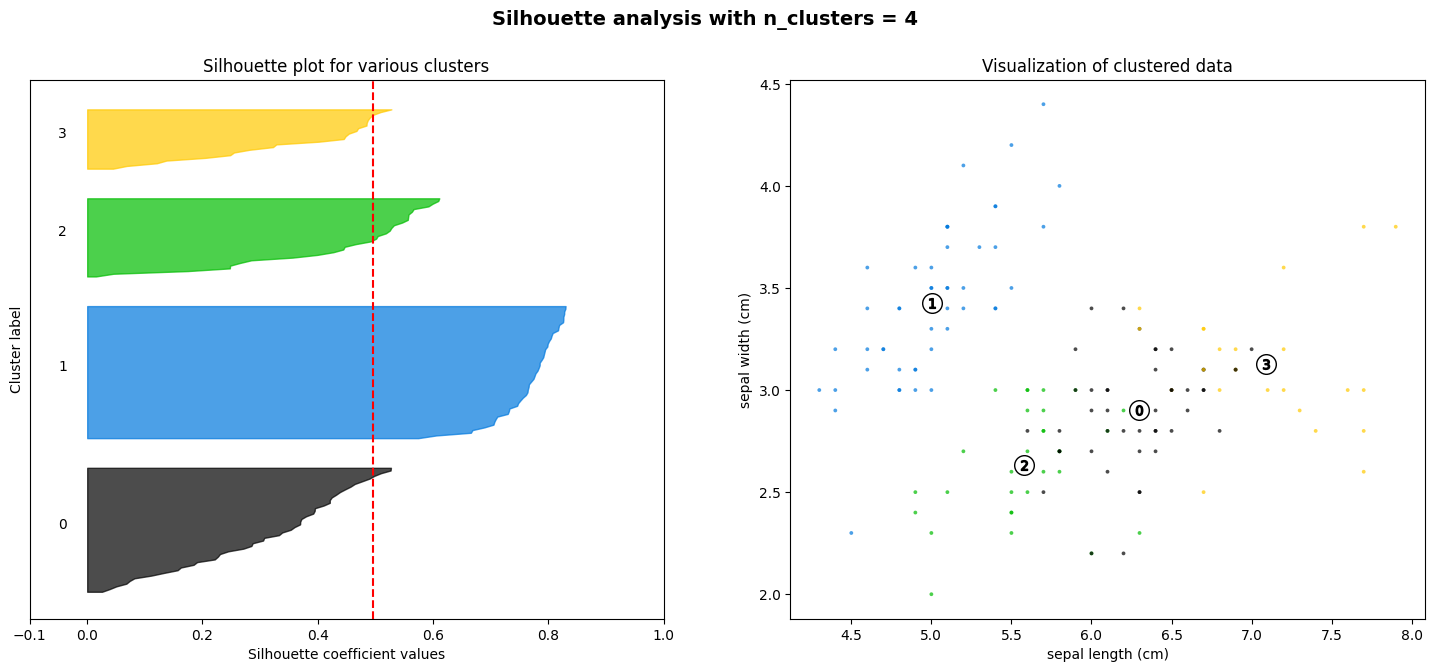

For n_clusters = 5 The average silhouette_score is : 0.4898982472843944


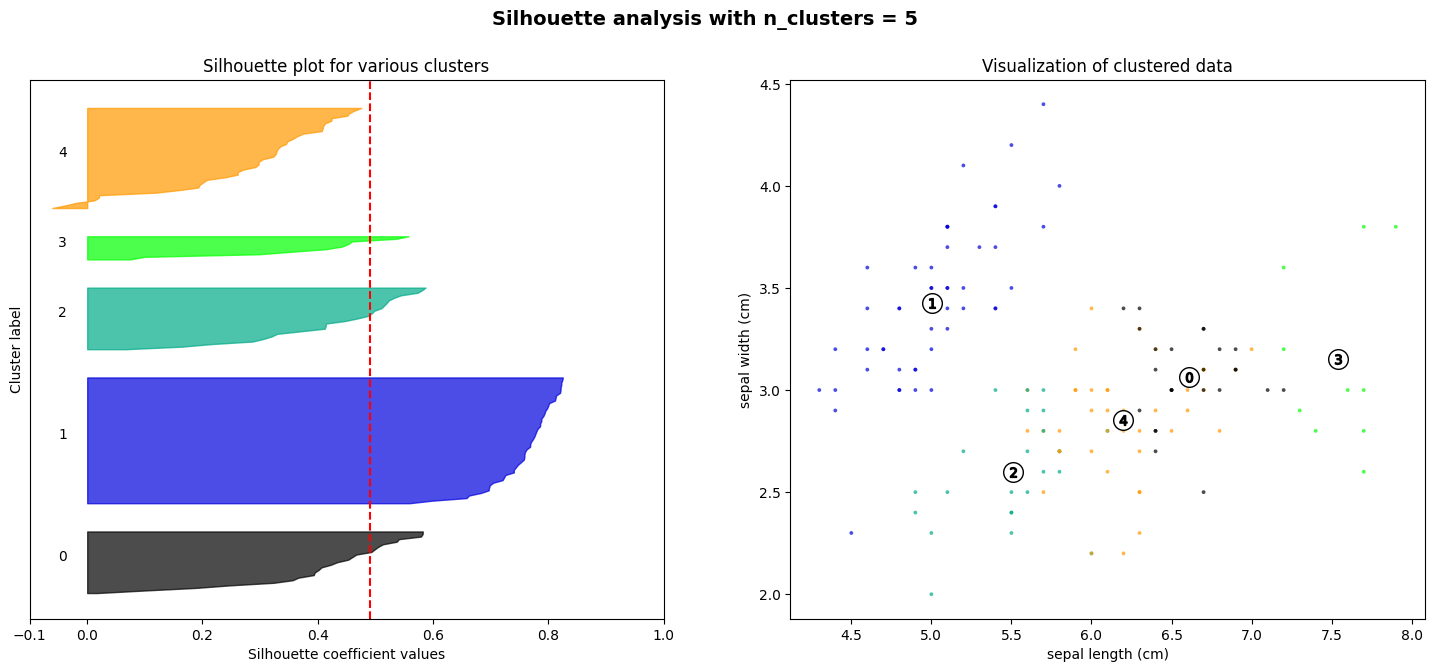

For n_clusters = 6 The average silhouette_score is : 0.4771175005821336


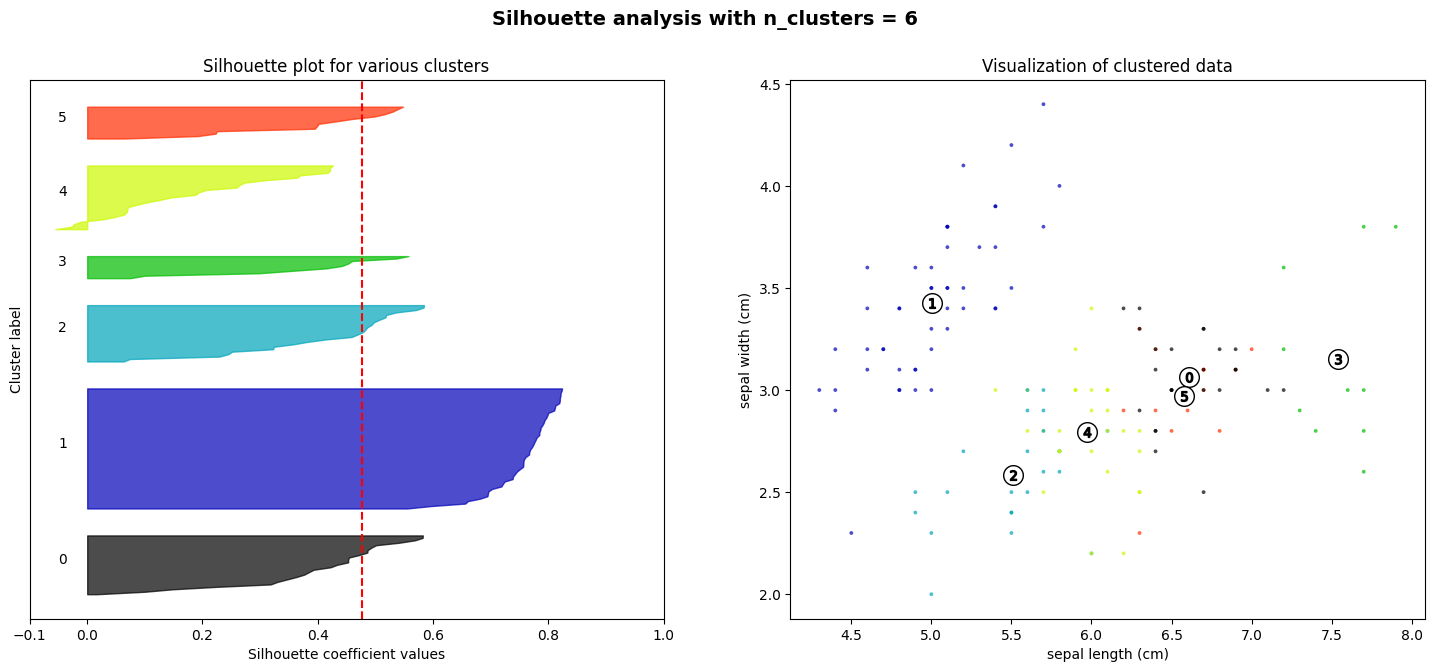

In [51]:
# 붓꽃의 원본 피처 4개만 선택
# 원본 피처 4개만 선택 (cluster, silhouette_coef 제외)
X = iris_df[['sepal length', 'sepal width',
             'petal length', 'petal width']]

for n_clusters in range_n_clusters:
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X)

    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =", n_clusters,
        "The average silhouette_score is :", silhouette_avg
    )

    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[
            cluster_labels == i
        ]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax1.set_title("Silhouette plot for various clusters")
    ax1.set_xlabel("Silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 두 번째 그래프: 첫 번째와 두 번째 피처로 군집 시각화
    colors = cm.nipy_spectral(
        cluster_labels.astype(float) / n_clusters
    )
    ax2.scatter(
        X.iloc[:, 0], X.iloc[:, 1],
        marker=".", s=30, lw=0, alpha=0.7,
        c=colors, edgecolor="k"
    )

    centers = clusterer.cluster_centers_
    ax2.scatter(
        centers[:, 0], centers[:, 1],
        marker="o", c="white", alpha=1, s=200, edgecolor="k"
    )

    for i, c in enumerate(centers):
        ax2.scatter(
            c[0], c[1], marker="$%d$" % i,
            alpha=1, s=50, edgecolor="k"
        )

    ax2.set_title("Visualization of clustered data")
    ax2.set_xlabel(iris.feature_names[0])
    ax2.set_ylabel(iris.feature_names[1])

    plt.suptitle(
        f"Silhouette analysis with n_clusters = {n_clusters}",
        fontsize=14,
        fontweight="bold",
    )

    plt.show()

붓꽃 데이터를 k-Means로 군집화할 경우에는 군집 개수를 2개로 하는 것이 가장 좋아 보입니다.
 3개의 경우 평균 실루엣 계수 값도 2개보다 작을뿐더러 1번 군집과 다른 0번, 2번 군집과의 실루엣 계수의 편차가 큽니다. 4개,5개의 경우도 마찬가지입니다.


실루엣 계수를 통한 k-Means 군집 평가 방법은 직관적으로 이해하기 쉽지만, 각 데이터별로 다른 데이터와의 거리를 반복적으로 계산해야 하므로 데이터양이 늘어나면 수행 시간이 크게 늘어나는 단점이 있습니다.